# quiz 1 基礎

In [33]:
import torch
import torch.nn as nn
import importlib
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from timm.data import resolve_model_data_config
from other_code import quiz1

importlib.reload(quiz1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [34]:
DATA_ROOT = Path("./dataset/Intel Image Classification")
CLASS_NAMES = [
    "buildings", "forest", "glacier",
    "mountain", "sea", "street"
]
VALID_EXTS = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp"
}

records = []

for split in ["seg_train", "seg_test", "seg_pred"]:
    split_dir = DATA_ROOT / split

    if not split_dir.is_dir():
        raise FileNotFoundError(f"找不到資料夾：{split_dir.resolve()}")

    if split != "seg_pred":
        for name in CLASS_NAMES:
            if not (split_dir / name).is_dir():
                raise FileNotFoundError(f"找不到類別資料夾：{split_dir / name}")

    paths = sorted(
        p for p in split_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in VALID_EXTS
    )

    for path in tqdm(paths, desc=f"檢查 {split}"):
        if split != "seg_pred":
            label = path.relative_to(split_dir).parts[0]
        else:
            label = None

        row = {
            "split": split,
            "path": str(path),
            "label": label,
            "width": None,
            "height": None,
            "mode": None,
            "error": None,
        }

        try:
            with Image.open(path) as img:
                img.load()
                row.update(
                    width=img.width,
                    height=img.height,
                    mode=img.mode,
                )
        except Exception as exc:
            row["error"] = str(exc)

        records.append(row)

image_df = pd.DataFrame(records)

if image_df.empty:
    raise ValueError("沒有找到圖片，請確認DATA_ROOT和副檔名。")

print("圖片總數：", len(image_df))
print("檢查表row/col：", image_df.shape)

print("\n各資料集圖片數：")
display(image_df.groupby("split").size().rename("count").to_frame())

print("\n各類圖片數：")
display(pd.crosstab(image_df["label"], image_df["split"]))

valid_df = image_df[image_df["error"].isna()].copy()

print("\n最常見的圖片尺寸(寬、高)：")
display(valid_df.groupby(["width", "height"]).size().sort_values(ascending=False).head(10).rename("count").to_frame())

print("\n圖片色彩模式：")
display(valid_df["mode"].value_counts().rename("count").to_frame())

bad_df = image_df[image_df["error"].notna()]
print("\n無法讀取的圖片數：", len(bad_df))
display(bad_df[["path", "error"]].head(10))

unexpected = (
    set(image_df["label"].dropna()) - set(CLASS_NAMES)
)
print("\n非預期的類別：", unexpected)

檢查 seg_pred: 100%|██████████| 7301/7301 [00:02<00:00, 3077.17it/s]

圖片總數： 24335
檢查表row/col： (24335, 7)

各資料集圖片數：


,count
split,
seg_pred,7301
seg_test,3000
seg_train,14034



各類圖片數：


split,seg_test,seg_train
label,,
buildings,437,2191
forest,474,2271
glacier,553,2404
mountain,525,2512
sea,510,2274
street,501,2382


...


圖片色彩模式：


,count
mode,
RGB,24335



無法讀取的圖片數： 0


,path,error



非預期的類別： set()


In [35]:
train_pool = valid_df[valid_df["split"] == "seg_train"].copy()
test_df = valid_df[valid_df["split"] == "seg_test"].copy()

train_df, val_df = train_test_split(train_pool, test_size=0.2, random_state=42, stratify=train_pool["label"])

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 11227
Val: 2807
Test: 3000


In [36]:
image_size = 224
Batch_size = 64
train_transform, eval_transform = quiz1.build_resnet_transforms(image_size)

train_set = quiz1.IntelDataset(train_df, train_transform)
val_set = quiz1.IntelDataset(val_df, eval_transform)
test_set = quiz1.IntelDataset(test_df, eval_transform)

train_loader = DataLoader(train_set, batch_size=Batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=Batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_set, batch_size=Batch_size, shuffle=False, num_workers=0)

In [37]:
Learning_rate = 1e-4
Weight_decay = 1e-4
Epochs = 20

model = quiz1.build_resnet50(num_classes=6, pretrained=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=Learning_rate, weight_decay=Weight_decay)

output_dir = Path("./result/resnet50")
output_dir.mkdir(parents=True, exist_ok=True)

checkpoint_path = output_dir / "best.pt"
history_path = output_dir / "history.csv"

history = []
best_val_loss = float("inf")

patience = 5
epochs_without_improvement = 0

for epoch in range(Epochs):
    train_loss, train_acc = quiz1.train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = quiz1.evaluate(model, val_loader, criterion, device)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })
    pd.DataFrame(history).to_csv(history_path, index=False)

    print(
        f"Epoch {epoch + 1}/{Epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_acc:.4f}"
    )
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0

        torch.save(model.state_dict(), checkpoint_path)
        print("已儲存最佳模型")
    else:
        epochs_without_improvement += 1
        print(
            f"Val loss 未改善：{epochs_without_improvement}/{patience}"
        )

    if epochs_without_improvement >= patience:
        print("Early stopping：停止訓練")
        break

print(f"\nBest val loss: {best_val_loss:.4f}")

Epoch 1/20 | Train loss: 0.4343 | Train acc: 0.8707 | Val loss: 0.1939 | Val acc: 0.9316
已儲存最佳模型


Epoch 2/20 | Train loss: 0.1763 | Train acc: 0.9392 | Val loss: 0.1866 | Val acc: 0.9316
已儲存最佳模型


Epoch 3/20 | Train loss: 0.1312 | Train acc: 0.9535 | Val loss: 0.1998 | Val acc: 0.9330
Val loss 未改善：1/5


Epoch 4/20 | Train loss: 0.1043 | Train acc: 0.9613 | Val loss: 0.2136 | Val acc: 0.9273
Val loss 未改善：2/5


Epoch 5/20 | Train loss: 0.0780 | Train acc: 0.9722 | Val loss: 0.2380 | Val acc: 0.9284
Val loss 未改善：3/5


Epoch 6/20 | Train loss: 0.0596 | Train acc: 0.9803 | Val loss: 0.3026 | Val acc: 0.9166
Val loss 未改善：4/5


Epoch 7/20 | Train loss: 0.0529 | Train acc: 0.9819 | Val loss: 0.2586 | Val acc: 0.9334
Val loss 未改善：5/5
Early stopping：停止訓練

Best val loss: 0.1866


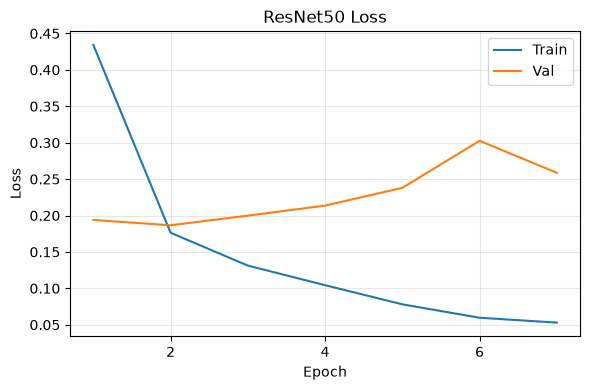

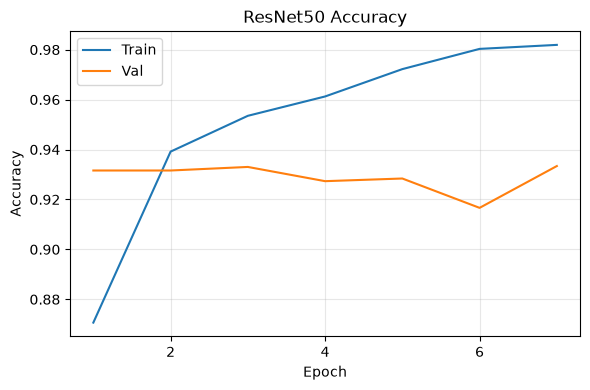

In [38]:
history_df = pd.read_csv("./result/resnet50/history.csv")

plt.figure(figsize=(6, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val")
plt.title("ResNet50 Loss")
plt.xlabel("Epoch")
plt.xticks(range(2, int(history_df["epoch"].max()) + 1, 2))
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./result/resnet50/loss.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train")
plt.plot(history_df["epoch"], history_df["val_acc"], label="Val")
plt.title("ResNet50 Accuracy")
plt.xlabel("Epoch")
plt.xticks(range(2, int(history_df["epoch"].max()) + 1, 2))
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./result/resnet50/accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

In [39]:
model.load_state_dict(torch.load("./result/resnet50/best.pt", map_location=device, weights_only=True))

test_loss, test_acc = quiz1.evaluate(model, test_loader, criterion, device)

print(f"Test loss: {test_loss:.4f}")
print(f"Test acc: {test_acc:.4f}")

Test loss: 0.1817
Test acc: 0.9347


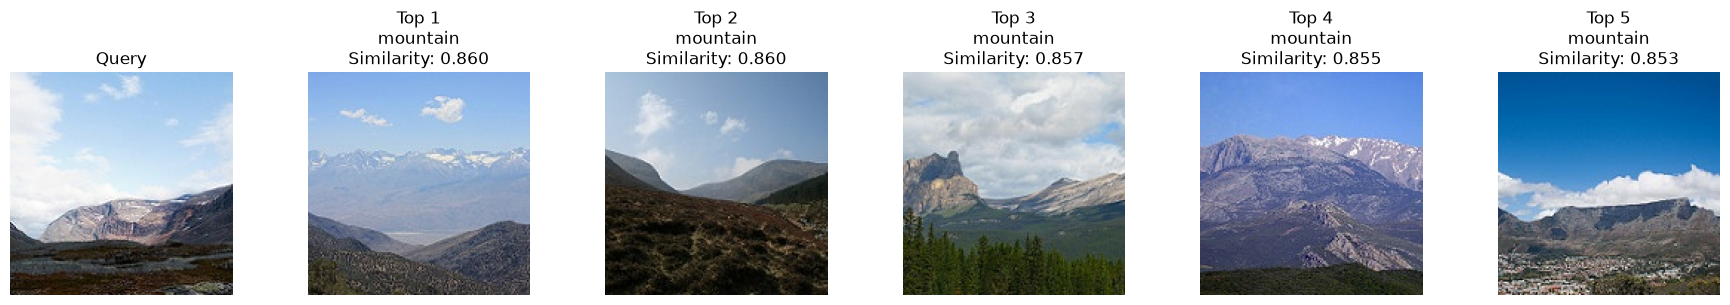

In [40]:
gallery_set = quiz1.IntelDataset(train_df, eval_transform)
gallery_loader = DataLoader(gallery_set, batch_size=Batch_size, shuffle=False, num_workers=0)

feature_model = quiz1.build_feature_model(model, model_type="resnet")
gallery_features, gallery_paths = quiz1.extract_features(feature_model, gallery_loader, device)

pred_df = valid_df[valid_df["split"] == "seg_pred"].reset_index(drop=True)
query_path = pred_df.iloc[1]["path"]

quiz1.show_retrieval(query_path=query_path, feature_model=feature_model, eval_transform=eval_transform, gallery_features=gallery_features,
                     gallery_paths=gallery_paths, device=device, save_path=output_dir / "retrieval_1.png")

# quiz 1 進階

In [41]:
model = quiz1.build_vit_small(num_classes=6, pretrained=True).to(device)
data_config = resolve_model_data_config(model)

train_transform, eval_transform = quiz1.build_vit_transforms(image_size=data_config["input_size"][-1],
                                                             mean=data_config["mean"],std=data_config["std"],)

train_set = quiz1.IntelDataset(train_df, train_transform)
val_set = quiz1.IntelDataset(val_df, eval_transform)
test_set = quiz1.IntelDataset(test_df, eval_transform)

train_loader = DataLoader(train_set, batch_size=Batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=Batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_set, batch_size=Batch_size, shuffle=False, num_workers=0)

In [42]:
Learning_rate = 1e-4
Weight_decay = 1e-4
Epochs = 20

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=Learning_rate, weight_decay=Weight_decay)

output_dir = Path("./result/vit_small")
output_dir.mkdir(parents=True, exist_ok=True)

checkpoint_path = output_dir / "best.pt"
history_path = output_dir / "history.csv"

history = []
best_val_loss = float("inf")

for epoch in range(Epochs):
    train_loss, train_acc = quiz1.train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = quiz1.evaluate(model, val_loader, criterion, device)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })
    pd.DataFrame(history).to_csv(history_path, index=False)

    print(
        f"Epoch {epoch + 1}/{Epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_acc:.4f}"
    )
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0

        torch.save(model.state_dict(), checkpoint_path)
        print("已儲存最佳模型")
    else:
        epochs_without_improvement += 1
        print(
            f"Val loss 未改善：{epochs_without_improvement}/{patience}"
        )

    if epochs_without_improvement >= patience:
        print("Early stopping：停止訓練")
        break

print(f"\nBest val loss: {best_val_loss:.4f}")

Epoch 1/20 | Train loss: 0.2283 | Train acc: 0.9182 | Val loss: 0.1646 | Val acc: 0.9430
已儲存最佳模型


Epoch 2/20 | Train loss: 0.1367 | Train acc: 0.9508 | Val loss: 0.1718 | Val acc: 0.9405
Val loss 未改善：1/5


Epoch 3/20 | Train loss: 0.1025 | Train acc: 0.9629 | Val loss: 0.1802 | Val acc: 0.9359
Val loss 未改善：2/5


Epoch 4/20 | Train loss: 0.0715 | Train acc: 0.9751 | Val loss: 0.2646 | Val acc: 0.9177
Val loss 未改善：3/5


Epoch 5/20 | Train loss: 0.0725 | Train acc: 0.9751 | Val loss: 0.2104 | Val acc: 0.9337
Val loss 未改善：4/5


Epoch 6/20 | Train loss: 0.0585 | Train acc: 0.9791 | Val loss: 0.2147 | Val acc: 0.9330
Val loss 未改善：5/5
Early stopping：停止訓練

Best val loss: 0.1646


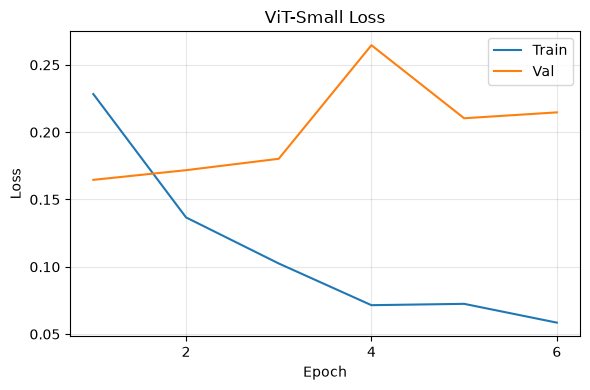

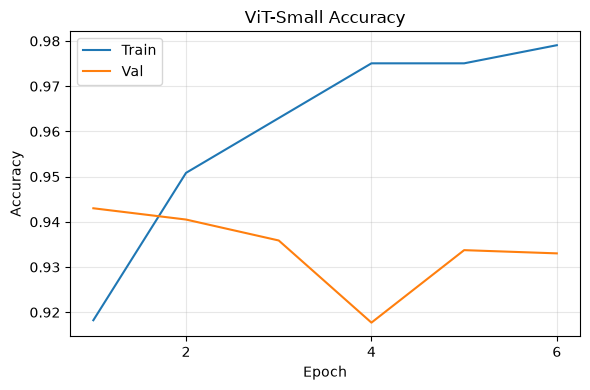

In [43]:
history_df = pd.read_csv("./result/vit_small/history.csv")

plt.figure(figsize=(6, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val")
plt.title("ViT-Small Loss")
plt.xlabel("Epoch")
plt.xticks(range(2, int(history_df["epoch"].max()) + 1, 2))
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./result/vit_small/loss.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train")
plt.plot(history_df["epoch"], history_df["val_acc"], label="Val")
plt.title("ViT-Small Accuracy")
plt.xlabel("Epoch")
plt.xticks(range(2, int(history_df["epoch"].max()) + 1, 2))
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./result/vit_small/accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

In [44]:
model.load_state_dict(torch.load("./result/vit_small/best.pt", map_location=device, weights_only=True))

test_loss, test_acc = quiz1.evaluate(model, test_loader, criterion, device)

print(f"Test loss: {test_loss:.4f}")
print(f"Test acc: {test_acc:.4f}")

Test loss: 0.1633
Test acc: 0.9397


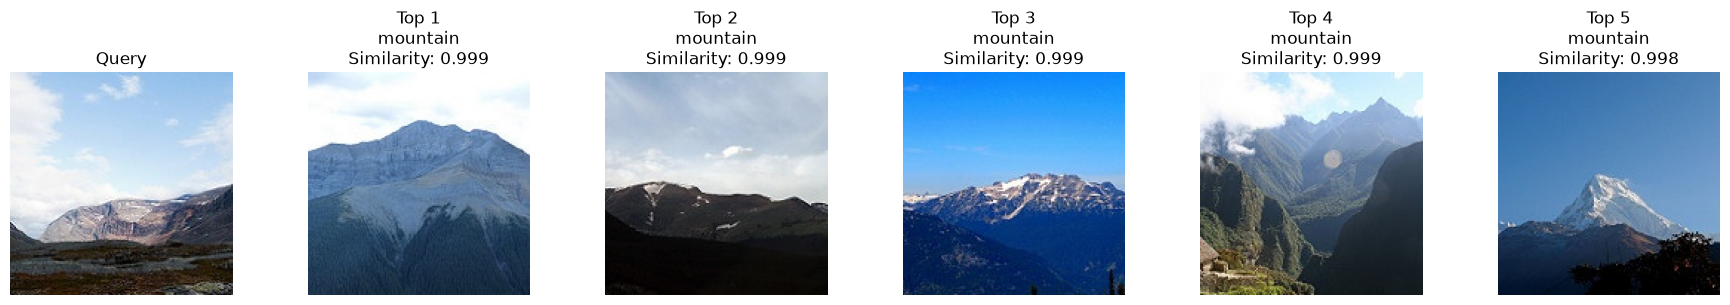

In [45]:
gallery_set = quiz1.IntelDataset(train_df, eval_transform)
gallery_loader = DataLoader(gallery_set, batch_size=Batch_size, shuffle=False, num_workers=0)

feature_model = quiz1.build_feature_model(model, model_type="resnet")
gallery_features, gallery_paths = quiz1.extract_features(feature_model, gallery_loader, device)

pred_df = valid_df[valid_df["split"] == "seg_pred"].reset_index(drop=True)
query_path = pred_df.iloc[1]["path"]

quiz1.show_retrieval(query_path=query_path, feature_model=feature_model, eval_transform=eval_transform, gallery_features=gallery_features,
                     gallery_paths=gallery_paths, device=device, save_path=output_dir / "retrieval_1.png")

# quiz 2 基礎

In [57]:
import torch
import importlib
import torch.nn as nn
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from torch.utils.data import DataLoader
from timm.data import resolve_model_data_config
from other_code import quiz2

importlib.reload(quiz2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [58]:
df = pd.read_csv("./dataset/Mini Fashion Product Images and Text Dataset/data.csv")

print("資料筆數與欄位數:", df.shape)
print("欄位:", df.columns.tolist())

display(df.head(3))
display(df.isna().sum().to_frame("missing_count"))

required_cols = ["image", "description", "category"]

clean_df = df.dropna(subset=required_cols).copy()

print("原本筆數:", len(df))
print("保留筆數:", len(clean_df))
print("排除筆數:", len(df) - len(clean_df))

資料筆數與欄位數: (44441, 4)
欄位: ['image', 'description', 'display name', 'category']


,image,description,display name,category
0,3238.jpg,"Round toed, black sports shoes with red accent...",Puma Men Black 65CC Lo Ducati Sports Shoes,Sports Shoes
1,43044.jpg,Style Note Built with the breathability and ze...,Nike Men Charcoal Grey Shorts,Shorts
2,54018.jpg,Teal handbag that has stitch detailing with a...,Kiara Women Teal Handbag,Handbags


,missing_count
image,0
description,281
display name,7
category,0


原本筆數: 44441
保留筆數: 44160
排除筆數: 281


圖片: dataset/Mini Fashion Product Images and Text Dataset/data/56282.jpg
類別: Bra
文字: Black coloured support brassiere made of stretchy cotton with full coverage Shoulders lined with lace Non-wired  Owing to the intimate nature of this product it is eligible for self-ship return only (no pick-up facility)


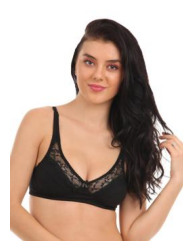

圖片: dataset/Mini Fashion Product Images and Text Dataset/data/49987.jpg
類別: Socks
文字: A pair of knit socks with stripes and branding on the foot Cushion MAX reinforced heel and toes for extra protection against impact Spandex for better Fit Shaped to fit the contours of the feet Please note that the actual product may vary in colour or print from the displayed image


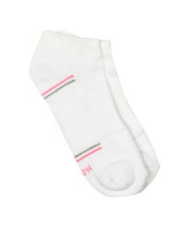

圖片: dataset/Mini Fashion Product Images and Text Dataset/data/9601.jpg
類別: Shirts
文字: Composition Blue and white check shirt with red accents, made of 100% cotton, has full arm sleeves with buttoned cuffs and mid-sleeve buttoned flap, front buttoned placket with metallic buttons, pockets on either chest with buttoned flaps and a curved hemline   Fitting  Slim   Wash care Pre-soak the garment before wash Preferably hand wash inside out with zippers and buttons fastened, using a mild detergents Wash dark colours separately Do not attempt to remove stains by spot washing Flat dry or drip dry on hanger and avoid wringing Preferably steam iron  Checks that add immense style to your casual look is what Sullers brings into your life. Be the cynosure of all eyes in this stylish shirt, while the fabric keeps you fresh and comfortable all day. The full arm sleeves add a touch of regality to your personality. Pair it with denims and sports shoes for that unparalleled cool.  Model statistics The m

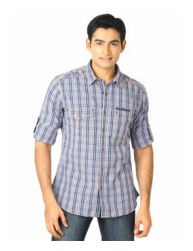

In [59]:
IMAGE_ROOT = Path("./dataset/Mini Fashion Product Images and Text Dataset/data")
IMAGE_COL = "image"
TEXT_COL = "description"
LABEL_COL = "category"

samples = clean_df.sample(n=min(3, len(clean_df)))

for _, row in samples.iterrows():
    image_path = IMAGE_ROOT / str(row[IMAGE_COL])

    print("圖片:", image_path)
    print("類別:", row[LABEL_COL])
    print("文字:", row[TEXT_COL])

    try:
        with Image.open(image_path) as img:
            image = img.convert("RGB")

        plt.figure(figsize=(3, 3))
        plt.imshow(image)
        plt.axis("off")
        plt.show()

    except Exception as exc:
        print("圖片讀取失敗:", exc)

In [60]:
class_counts = clean_df[LABEL_COL].value_counts()
display(class_counts.to_frame("count"))

keep_classes = class_counts[class_counts >= 10].index
filtered_df = clean_df[clean_df[LABEL_COL].isin(keep_classes)].copy()

print("保留類別數:", len(keep_classes))
print("保留資料筆數:", len(filtered_df))
print("排除資料筆數:", len(clean_df) - len(filtered_df))

,count
category,
Tshirts,7053
Shirts,3163
Casual Shoes,2841
Watches,2516
Sports Shoes,2035
...,...
Ipad,1
Cushion Covers,1
Mens Grooming Kit,1


保留類別數: 107
保留資料筆數: 44007
排除資料筆數: 153


In [61]:
train_df, remaining_df = train_test_split(filtered_df, test_size=0.2, random_state=42, stratify=filtered_df[LABEL_COL])
val_df, test_df = train_test_split(remaining_df, test_size=0.5, random_state=42, stratify=remaining_df[LABEL_COL])

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

class_names = sorted(filtered_df[LABEL_COL].unique().tolist())
class_to_idx = {name: index for index, name in enumerate(class_names)}

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))
print("類別對照:", class_to_idx)

Train: 35205
Val: 4401
Test: 4401
類別對照: {'Accessory Gift Set': 0, 'Baby Dolls': 1, 'Backpacks': 2, 'Bangle': 3, 'Basketballs': 4, 'Bath Robe': 5, 'Belts': 6, 'Booties': 7, 'Boxers': 8, 'Bra': 9, 'Bracelet': 10, 'Briefs': 11, 'Camisoles': 12, 'Capris': 13, 'Caps': 14, 'Casual Shoes': 15, 'Churidar': 16, 'Clutches': 17, 'Compact': 18, 'Concealer': 19, 'Cufflinks': 20, 'Deodorant': 21, 'Dresses': 22, 'Duffel Bag': 23, 'Dupatta': 24, 'Earrings': 25, 'Eyeshadow': 26, 'Face Moisturisers': 27, 'Face Wash and Cleanser': 28, 'Flats': 29, 'Flip Flops': 30, 'Formal Shoes': 31, 'Foundation and Primer': 32, 'Fragrance Gift Set': 33, 'Free Gifts': 34, 'Gloves': 35, 'Hair Colour': 36, 'Handbags': 37, 'Heels': 38, 'Highlighter and Blush': 39, 'Innerwear Vests': 40, 'Jackets': 41, 'Jeans': 42, 'Jeggings': 43, 'Jewellery Set': 44, 'Jumpsuit': 45, 'Kajal and Eyeliner': 46, 'Kurta Sets': 47, 'Kurtas': 48, 'Kurtis': 49, 'Laptop Bag': 50, 'Leggings': 51, 'Lip Care': 52, 'Lip Gloss': 53, 'Lip Liner': 54, 'Li

In [62]:
Batch_size = 64

text_model_name = "distilbert/distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(text_model_name)
train_transform, eval_transform = quiz2.build_transforms()

dataset_kwargs = {
    "image_root": IMAGE_ROOT,
    "image_col": IMAGE_COL,
    "text_col": TEXT_COL,
    "label_col": LABEL_COL,
    "class_to_idx": class_to_idx,
    "tokenizer": tokenizer,
    "max_length": 64,
}

train_set = quiz2.FashionDataset(train_df, transform=train_transform, **dataset_kwargs)
val_set = quiz2.FashionDataset(val_df, transform=eval_transform, **dataset_kwargs)
test_set = quiz2.FashionDataset(test_df, transform=eval_transform, **dataset_kwargs)

train_loader = DataLoader(train_set, batch_size=Batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=Batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_set, batch_size=Batch_size, shuffle=False, num_workers=0)

/root/venvs/torch-cu121/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [63]:
model = quiz2.MultimodalClassifier(num_classes=len(class_names), image_backbone="resnet18").to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW([
    {"params": model.image_encoder.parameters(), "lr": 1e-4},
    {"params": model.text_encoder.parameters(), "lr": 2e-5},
    {"params": model.classifier.parameters(), "lr": 1e-3},
], weight_decay=1e-4)

In [64]:
Epochs = 20
patience = 5

output_dir = Path("./result/resnet18_distilbert")
output_dir.mkdir(parents=True, exist_ok=True)

checkpoint_path = output_dir / "best.pt"
history_path = output_dir / "history.csv"

history = []
best_val_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(Epochs):
    train_loss, train_acc = quiz2.train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = quiz2.evaluate(model, val_loader, criterion, device)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })

    pd.DataFrame(history).to_csv(history_path, index=False)

    print(
        f"Epoch {epoch + 1}/{Epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0

        torch.save(model.state_dict(), checkpoint_path)
        print("已儲存最佳模型")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping：停止訓練")
        break

print(f"Best val loss: {best_val_loss:.4f}")

Epoch 1/20 | Train loss: 0.6211 | Train acc: 0.8443 | Val loss: 0.3097 | Val acc: 0.9034
已儲存最佳模型


Epoch 2/20 | Train loss: 0.2345 | Train acc: 0.9305 | Val loss: 0.2406 | Val acc: 0.9262
已儲存最佳模型


Epoch 3/20 | Train loss: 0.1693 | Train acc: 0.9479 | Val loss: 0.2340 | Val acc: 0.9359
已儲存最佳模型


Epoch 4/20 | Train loss: 0.1299 | Train acc: 0.9594 | Val loss: 0.2337 | Val acc: 0.9337
已儲存最佳模型


Epoch 5/20 | Train loss: 0.1109 | Train acc: 0.9648 | Val loss: 0.2441 | Val acc: 0.9380


Epoch 6/20 | Train loss: 0.0895 | Train acc: 0.9716 | Val loss: 0.2405 | Val acc: 0.9414


Epoch 7/20 | Train loss: 0.0773 | Train acc: 0.9747 | Val loss: 0.2627 | Val acc: 0.9396


Epoch 8/20 | Train loss: 0.0665 | Train acc: 0.9798 | Val loss: 0.2606 | Val acc: 0.9452


Epoch 9/20 | Train loss: 0.0586 | Train acc: 0.9809 | Val loss: 0.3264 | Val acc: 0.9425
Early stopping：停止訓練
Best val loss: 0.2337


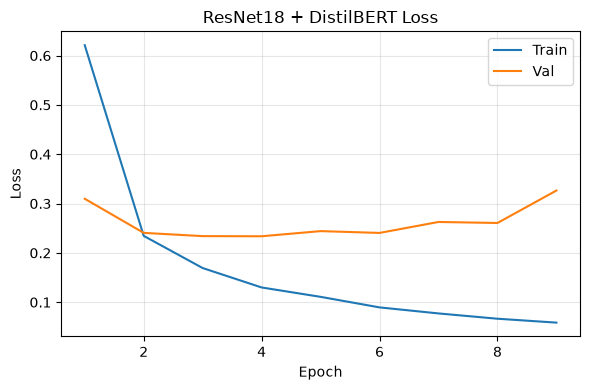

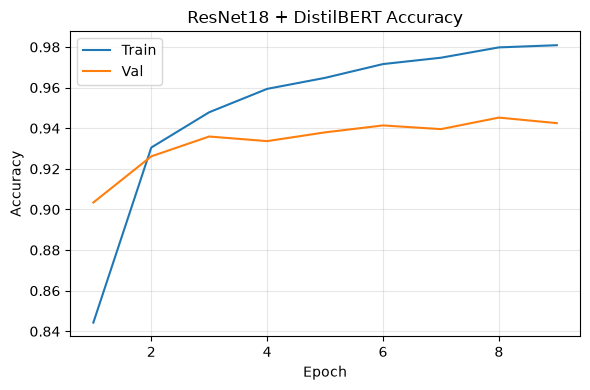

In [65]:
history_df = pd.read_csv("./result/resnet18_distilbert/history.csv")

plt.figure(figsize=(6, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val")
plt.title("ResNet18 + DistilBERT Loss")
plt.xlabel("Epoch")
plt.xticks(range(2, int(history_df["epoch"].max()) + 1, 2))
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./result/resnet18_distilbert/loss.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train")
plt.plot(history_df["epoch"], history_df["val_acc"], label="Val")
plt.title("ResNet18 + DistilBERT Accuracy")
plt.xlabel("Epoch")
plt.xticks(range(2, int(history_df["epoch"].max()) + 1, 2))
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./result/resnet18_distilbert/accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

In [66]:
model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
test_loss, test_acc = quiz2.evaluate(model, test_loader, criterion, device)

print(f"Test loss: {test_loss:.4f}")
print(f"Test acc: {test_acc:.4f}")

Test loss: 0.1971
Test acc: 0.9436


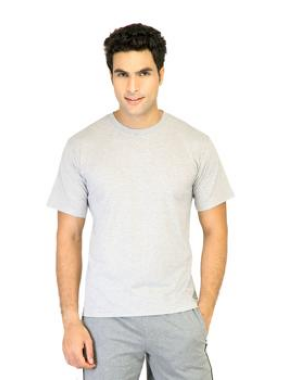

文字: The final product delivered might vary in colour and prints from the display here. Composition Pack of 3 t-shirts  Grey T-shirt made of ComfortSoft 100% combed cotton, has a lay flat collar, crew neck, fabric tape on the inseam of the back shoulder and neck, and short sleeves   Fit  Comfort   Wash care  Machine wash warm with like colours Do not bleach Tumble dry low Warm iron  Lightweight with a round neck, these hanes short-sleeved t-shirts in ComfortSoft cotton are stylish, and yet relaxed. The lay flat collar never stretches out of shape even after repeated washes, while the fabric simply flows over your torso. Perfect on its own with jeans, this T-shirt also works great with shorts and track pants.   Model statistics  The model wears size M in T-shirts Height: 6', Shoulders: 19"
真實類別: Innerwear Vests
預測類別: Innerwear Vests
是否正確: True


In [67]:
index = 0

image, input_ids, attention_mask, label = test_set[index]
model.eval()
with torch.no_grad():
    outputs = model(image.unsqueeze(0).to(device), input_ids.unsqueeze(0).to(device), attention_mask.unsqueeze(0).to(device))
    predicted_id = outputs.argmax(dim=1).item()

row = test_set.dataframe.iloc[index]
image_path = IMAGE_ROOT / str(row[IMAGE_COL])

with Image.open(image_path) as img:
    original_image = img.convert("RGB")

plt.figure(figsize=(4, 4))
plt.imshow(original_image)
plt.axis("off")
plt.tight_layout()
plt.show()

idx_to_class = {index: name for name, index in class_to_idx.items()}

print("文字:", test_set.dataframe.iloc[index][TEXT_COL])
print("真實類別:", idx_to_class[label])
print("預測類別:", idx_to_class[predicted_id])
print("是否正確:", predicted_id == label)

# quiz 2 進階

In [68]:
Batch_size = 64

text_model_name = "distilbert/distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(text_model_name)

model = quiz2.MultimodalClassifier(num_classes=len(class_names), image_backbone="vit_tiny").to(device)
data_config = resolve_model_data_config(model.image_encoder)
train_transform, eval_transform = quiz2.build_transforms(image_size=data_config["input_size"][-1],
                                                         mean=data_config["mean"], std=data_config["std"])

dataset_kwargs = {
    "image_root": IMAGE_ROOT,
    "image_col": IMAGE_COL,
    "text_col": TEXT_COL,
    "label_col": LABEL_COL,
    "class_to_idx": class_to_idx,
    "tokenizer": tokenizer,
    "max_length": 64,
}

train_set = quiz2.FashionDataset(train_df, transform=train_transform, **dataset_kwargs)
val_set = quiz2.FashionDataset(val_df, transform=eval_transform, **dataset_kwargs)
test_set = quiz2.FashionDataset(test_df, transform=eval_transform, **dataset_kwargs)

train_loader = DataLoader(train_set, batch_size=Batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=Batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_set, batch_size=Batch_size, shuffle=False, num_workers=0)

/root/venvs/torch-cu121/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [69]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW([
    {"params": model.image_encoder.parameters(), "lr": 1e-4},
    {"params": model.text_encoder.parameters(), "lr": 2e-5},
    {"params": model.classifier.parameters(), "lr": 1e-3},
], weight_decay=1e-4)

In [70]:
Epochs = 20
patience = 5

output_dir = Path("./result/vit_tiny_distilbert")
output_dir.mkdir(parents=True, exist_ok=True)

checkpoint_path = output_dir / "best.pt"
history_path = output_dir / "history.csv"

history = []
best_val_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(Epochs):
    train_loss, train_acc = quiz2.train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = quiz2.evaluate(model, val_loader, criterion, device)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })

    pd.DataFrame(history).to_csv(history_path, index=False)

    print(
        f"Epoch {epoch + 1}/{Epochs} | "
        f"Train loss: {train_loss:.4f} | "
        f"Train acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f} | "
        f"Val acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_without_improvement = 0

        torch.save(model.state_dict(), checkpoint_path)
        print("已儲存最佳模型")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping：停止訓練")
        break

print(f"Best val loss: {best_val_loss:.4f}")

Epoch 1/20 | Train loss: 0.5196 | Train acc: 0.8610 | Val loss: 0.2762 | Val acc: 0.9182
已儲存最佳模型


Epoch 2/20 | Train loss: 0.2130 | Train acc: 0.9351 | Val loss: 0.2502 | Val acc: 0.9296
已儲存最佳模型


Epoch 3/20 | Train loss: 0.1596 | Train acc: 0.9499 | Val loss: 0.2354 | Val acc: 0.9368
已儲存最佳模型


Epoch 4/20 | Train loss: 0.1322 | Train acc: 0.9582 | Val loss: 0.2493 | Val acc: 0.9316


Epoch 5/20 | Train loss: 0.1118 | Train acc: 0.9640 | Val loss: 0.2393 | Val acc: 0.9375


Epoch 6/20 | Train loss: 0.0865 | Train acc: 0.9714 | Val loss: 0.2734 | Val acc: 0.9402


Epoch 7/20 | Train loss: 0.0788 | Train acc: 0.9750 | Val loss: 0.2777 | Val acc: 0.9407


Epoch 8/20 | Train loss: 0.0675 | Train acc: 0.9776 | Val loss: 0.3153 | Val acc: 0.9391
Early stopping：停止訓練
Best val loss: 0.2354


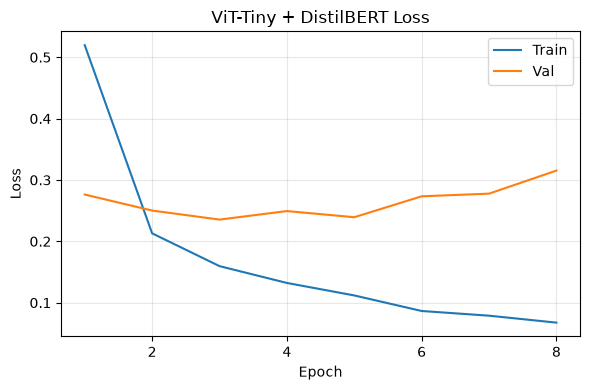

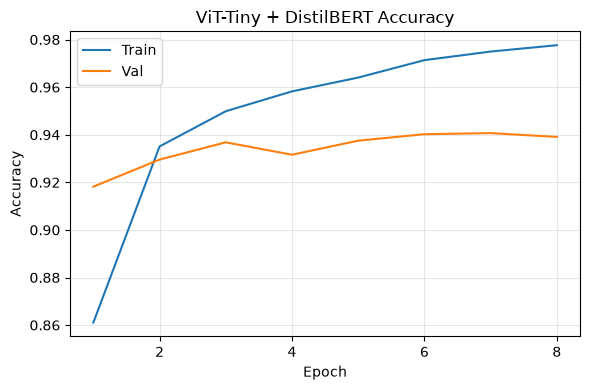

In [71]:
history_df = pd.read_csv("./result/vit_tiny_distilbert/history.csv")

plt.figure(figsize=(6, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val")
plt.title("ViT-Tiny + DistilBERT Loss")
plt.xlabel("Epoch")
plt.xticks(range(2, int(history_df["epoch"].max()) + 1, 2))
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./result/vit_tiny_distilbert/loss.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train")
plt.plot(history_df["epoch"], history_df["val_acc"], label="Val")
plt.title("ViT-Tiny + DistilBERT Accuracy")
plt.xlabel("Epoch")
plt.xticks(range(2, int(history_df["epoch"].max()) + 1, 2))
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("./result/vit_tiny_distilbert/accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

In [72]:
model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
test_loss, test_acc = quiz2.evaluate(model, test_loader, criterion, device)

print(f"Test loss: {test_loss:.4f}")
print(f"Test acc: {test_acc:.4f}")

Test loss: 0.2056
Test acc: 0.9436


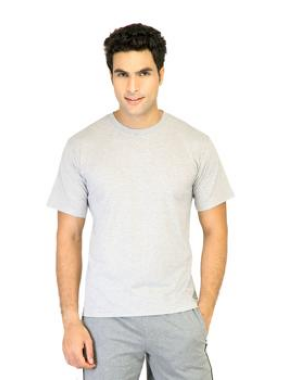

文字: The final product delivered might vary in colour and prints from the display here. Composition Pack of 3 t-shirts  Grey T-shirt made of ComfortSoft 100% combed cotton, has a lay flat collar, crew neck, fabric tape on the inseam of the back shoulder and neck, and short sleeves   Fit  Comfort   Wash care  Machine wash warm with like colours Do not bleach Tumble dry low Warm iron  Lightweight with a round neck, these hanes short-sleeved t-shirts in ComfortSoft cotton are stylish, and yet relaxed. The lay flat collar never stretches out of shape even after repeated washes, while the fabric simply flows over your torso. Perfect on its own with jeans, this T-shirt also works great with shorts and track pants.   Model statistics  The model wears size M in T-shirts Height: 6', Shoulders: 19"
真實類別: Innerwear Vests
預測類別: Innerwear Vests
是否正確: True


In [73]:
index = 0

image, input_ids, attention_mask, label = test_set[index]
model.eval()
with torch.no_grad():
    outputs = model(image.unsqueeze(0).to(device), input_ids.unsqueeze(0).to(device), attention_mask.unsqueeze(0).to(device))
    predicted_id = outputs.argmax(dim=1).item()

row = test_set.dataframe.iloc[index]
image_path = IMAGE_ROOT / str(row[IMAGE_COL])

with Image.open(image_path) as img:
    original_image = img.convert("RGB")

plt.figure(figsize=(4, 4))
plt.imshow(original_image)
plt.axis("off")
plt.tight_layout()
plt.show()

idx_to_class = {index: name for name, index in class_to_idx.items()}

print("文字:", test_set.dataframe.iloc[index][TEXT_COL])
print("真實類別:", idx_to_class[label])
print("預測類別:", idx_to_class[predicted_id])
print("是否正確:", predicted_id == label)